In [1]:
!pip install mlflow
!pip install nltk

  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached gunicorn-25.1.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.13.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached databricks_sdk-0.96.0-py3-none-any.whl.metadata (40 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached p

In [2]:
!pip install protobuf==4.25.3


  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.5
    Uninstalling protobuf-6.33.5:
      Successfully uninstalled protobuf-6.33.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.40.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
databricks-sdk 0.96.0 requires protobuf!=5.26.*,!=5.27.*,!=5.28.*,!=5.29.0,!=5.29.1,!=5.29.2,!=5.29.3,!=5.29.4,!=6.30.0,!=6.30.1,!=6.31.0,<7.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, classification_report

from tqdm import tqdm

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import Callback


# CONFIGURACIÓN MLFLOW

mlflow.set_tracking_uri("http://ec2-54-167-162-85.compute-1.amazonaws.com:5000")
experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# OUTPUT FOLDERS

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# CARGAR DATASET

train_df = pd.read_csv("data_nopunct_elongation/train_final.csv")
test_df = pd.read_csv("data_nopunct_elongation/test_final.csv")

train_df = train_df.sample(1000000, random_state=42)

print(train_df.head())


# FEATURES

X_train = train_df["text"]
y_train = train_df["label"].values

X_test = test_df["text"]
y_test = test_df["label"].values


# TFIDF

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000
)

print("\nFitting TFIDF...")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# SVD

print("\nApplying SVD dimensionality reduction...")

svd = TruncatedSVD(n_components=300, random_state=42)

X_train_vec = svd.fit_transform(X_train_tfidf)
X_test_vec = svd.transform(X_test_tfidf)

input_dim = X_train_vec.shape[1]

print("Final feature dimension:", input_dim)


# CALLBACK PARA TQDM

class TQDMProgressBar(Callback):

    def on_train_begin(self, logs=None):
        self.epochs = self.params["epochs"]
        self.pbar = tqdm(total=self.epochs, desc="Training Progress")

    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)

    def on_train_end(self, logs=None):
        self.pbar.close()


# FUNCIÓN RED NEURONAL

def create_model():

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


# CONFIGURACIONES

experiments = [
    {"batch_size": 32, "epochs": 5},
    {"batch_size": 64, "epochs": 5},
    {"batch_size": 32, "epochs": 10}
]


ablation_results = []


# LOOP EXPERIMENTOS

for exp in experiments:

    batch_size = exp["batch_size"]
    epochs = exp["epochs"]

    run_name = f"NN_batch{batch_size}_epochs{epochs}"

    print(f"\nRunning experiment {run_name}")


    with mlflow.start_run(run_name=run_name):

        # TAGS (AQUÍ SE AGREGAN)

        mlflow.set_tags({
            "project": "NLP Sentiment Analysis",
            "dataset": "train_final.csv",
            "task": "text_classification",
            "model_type": "Neural Network",
            "feature_type": "TFIDF + SVD",
            "author": "Nicolas"
        })


        start_time = time.time()

        model = create_model()

        model.fit(
            X_train_vec,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[TQDMProgressBar()]
        )

        y_pred = (model.predict(X_test_vec) > 0.5).astype(int)

        runtime = time.time() - start_time

        f1 = f1_score(y_test, y_pred, average="weighted")


        # PARAMS

        mlflow.log_params({
            "vectorizer": "TFIDF",
            "ngram_range": "1,2",
            "max_features": 20000,
            "dimensionality_reduction": "SVD",
            "svd_components": 300,
            "model": "NeuralNetwork",
            "architecture": "512-128-1",
            "batch_size": batch_size,
            "epochs": epochs
        })


        # MÉTRICAS

        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)


        # MODEL CARD

        model_card = {
            "model_name": run_name,
            "vectorizer": "TFIDF",
            "max_features": 20000,
            "dimensionality_reduction": "SVD",
            "svd_components": 300,
            "classifier": "NeuralNetwork",
            "architecture": "512-128-1",
            "epochs": epochs,
            "batch_size": batch_size,
            "f1_score": float(f1),
            "author": "Nicolas"
        }

        model_card_path = f"outputs/model/model_card_{run_name}.json"

        with open(model_card_path, "w") as f:
            json.dump(model_card, f, indent=4)


        ablation_results.append({
            "vectorizer": "TFIDF",
            "model": "NeuralNetwork",
            "epochs": epochs,
            "batch_size": batch_size,
            "f1_score": f1
        })


        mlflow.log_artifact(model_card_path)

        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))


# RESULTADOS FINALES

ablation_df = pd.DataFrame(ablation_results)

ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)


plt.figure()

plt.bar(
    ablation_df["epochs"].astype(str),
    ablation_df["f1_score"]
)

plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("Neural Network Experiments")

plt.savefig("outputs/reports/ablation_plot.png")


print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)

                                                      text  label
128701   i miss my friends so much  i  you guys you mea...      0
332366   im going to study very hard todaywell at least...      1
1261878  shit back home in tallcree rez  now i cant see...      0
1252792                          help gear indexing again       0
1130754  what a glorious day after a busy monday then i...      0

Fitting TFIDF...

Applying SVD dimensionality reduction...
Final feature dimension: 300

Running experiment NN_batch32_epochs5


2026-03-09 03:19:21.020733: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1200000000 exceeds 10% of free system memory.
Training Progress: 100%|██████████| 5/5 [06:27<00:00, 77.43s/it]


7500/7500 [==============================] - 9s 1ms/step

Ejecución Exitosa
F1 Score: 0.7770708200929947
Runtime: 457.6687762737274

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.77      0.78    120129
           1       0.77      0.79      0.78    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run NN_batch32_epochs5 at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8/runs/4a81db07caa5416f99eb5628355bd56d
🧪 View experiment at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8

Running experiment NN_batch64_epochs5


2026-03-09 03:26:59.112740: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1200000000 exceeds 10% of free system memory.
Training Progress: 100%|██████████| 5/5 [03:47<00:00, 45.53s/it]


7500/7500 [==============================] - 9s 1ms/step

Ejecución Exitosa
F1 Score: 0.7763292126750411
Runtime: 241.75102543830872

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.80      0.78    120129
           1       0.79      0.75      0.77    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run NN_batch64_epochs5 at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8/runs/e3abe5f38e924760bfb981a6a243ef4d
🧪 View experiment at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8

Running experiment NN_batch32_epochs10


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


                                                      text  label
128701   i miss my friends so much  i  you guys you mea...      0
332366   im going to study very hard todaywell at least...      1
1261878  shit back home in tallcree rez  now i cant see...      0
1252792                          help gear indexing again       0
1130754  what a glorious day after a busy monday then i...      0

Fitting TFIDF...
Final feature dimension: 10000

Running experiment NN_batch256_epochs5

Training Progress:


Epoch 5/5: 100%|██████████| 5/5 [08:57<00:00, 107.56s/it]



Ejecución Exitosa
F1 Score: 0.7915051790401543
Runtime: 539.5105602741241

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.79      0.79    120129
           1       0.79      0.80      0.79    119871

    accuracy                           0.79    240000
   macro avg       0.79      0.79      0.79    240000
weighted avg       0.79      0.79      0.79    240000

🏃 View run NN_batch256_epochs5 at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8/runs/c9471471192f4ef89cccdb83cdebdcd9
🧪 View experiment at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8

Running experiment NN_batch512_epochs5

Training Progress:


Epoch 5/5: 100%|██████████| 5/5 [04:40<00:00, 56.08s/it]



Ejecución Exitosa
F1 Score: 0.7967415912070047
Runtime: 281.035142660141

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.80      0.80    120129
           1       0.80      0.80      0.80    119871

    accuracy                           0.80    240000
   macro avg       0.80      0.80      0.80    240000
weighted avg       0.80      0.80      0.80    240000

🏃 View run NN_batch512_epochs5 at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8/runs/548e42cb276a4dc18198ef32e75a2fb9
🧪 View experiment at: http://ec2-54-167-162-85.compute-1.amazonaws.com:5000/#/experiments/8

Todos los experimentos terminaron correctamente

Resultados finales:
  vectorizer          model  epochs  batch_size  f1_score
0      TFIDF  NeuralNetwork       5         256  0.791505
1      TFIDF  NeuralNetwork       5         512  0.796742


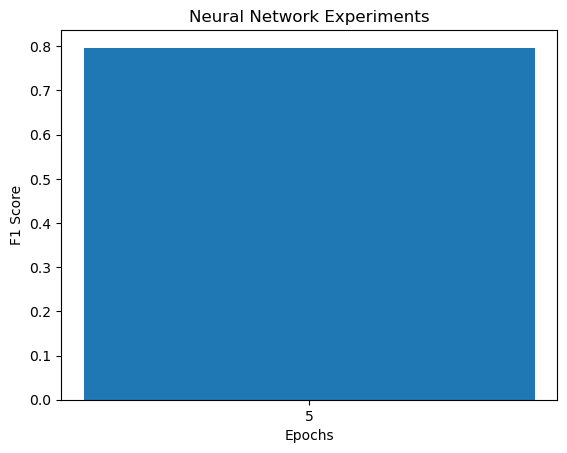

In [3]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.neural_network import MLPClassifier

from tqdm import tqdm


# CONFIGURACIÓN MLFLOW

mlflow.set_tracking_uri("http://ec2-54-167-162-85.compute-1.amazonaws.com:5000")
experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# OUTPUT FOLDERS

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# CARGAR DATASET

train_df = pd.read_csv("data_nopunct_elongation/train_final.csv")
test_df = pd.read_csv("data_nopunct_elongation/test_final.csv")

train_df = train_df.sample(800000, random_state=42)

print(train_df.head())


# FEATURES

X_train = train_df["text"]
y_train = train_df["label"].values

X_test = test_df["text"]
y_test = test_df["label"].values


# TFIDF

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=10000
)

print("\nFitting TFIDF...")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

input_dim = X_train_vec.shape[1]

print("Final feature dimension:", input_dim)


# CONFIGURACIONES

experiments = [
    {"batch_size": 256, "epochs": 5},
    {"batch_size": 512, "epochs": 5}
]


ablation_results = []


# LOOP EXPERIMENTOS

for exp in experiments:

    batch_size = exp["batch_size"]
    epochs = exp["epochs"]

    run_name = f"NN_batch{batch_size}_epochs{epochs}"

    print(f"\nRunning experiment {run_name}")


    with mlflow.start_run(run_name=run_name):

        mlflow.set_tags({
            "project": "NLP Sentiment Analysis",
            "dataset": "train_final.csv",
            "task": "text_classification",
            "model_type": "Neural Network",
            "feature_type": "TFIDF",
            "author": "Nicolas"
        })


        start_time = time.time()


        # RED NEURONAL (MLP)

        model = MLPClassifier(
            hidden_layer_sizes=(128,32),
            activation="relu",
            solver="adam",
            batch_size=batch_size,
            max_iter=1,
            warm_start=True,
            random_state=42
        )

        classes = np.unique(y_train)

        print("\nTraining Progress:")

        pbar = tqdm(range(epochs))

        for epoch in pbar:

            if epoch == 0:
                model.partial_fit(X_train_vec, y_train, classes=classes)
            else:
                model.partial_fit(X_train_vec, y_train)

            pbar.set_description(f"Epoch {epoch+1}/{epochs}")


        y_pred = model.predict(X_test_vec)


        runtime = time.time() - start_time

        f1 = f1_score(y_test, y_pred, average="weighted")


        # PARAMS

        mlflow.log_params({
            "vectorizer": "TFIDF",
            "ngram_range": "1,2",
            "max_features": 20000,
            "model": "MLPClassifier",
            "architecture": "128-32-1",
            "batch_size": batch_size,
            "epochs": epochs
        })


        # MÉTRICAS

        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)


        # MODEL CARD

        model_card = {
            "model_name": run_name,
            "vectorizer": "TFIDF",
            "max_features": 20000,
            "classifier": "MLPClassifier",
            "architecture": "128-32-1",
            "epochs": epochs,
            "batch_size": batch_size,
            "f1_score": float(f1),
            "author": "Nicolas"
        }

        model_card_path = f"outputs/model/model_card_{run_name}.json"

        with open(model_card_path, "w") as f:
            json.dump(model_card, f, indent=4)


        ablation_results.append({
            "vectorizer": "TFIDF",
            "model": "NeuralNetwork",
            "epochs": epochs,
            "batch_size": batch_size,
            "f1_score": f1
        })


        mlflow.log_artifact(model_card_path)

        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))


# RESULTADOS FINALES

ablation_df = pd.DataFrame(ablation_results)

ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)


plt.figure()

plt.bar(
    ablation_df["epochs"].astype(str),
    ablation_df["f1_score"]
)

plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("Neural Network Experiments")

plt.savefig("outputs/reports/ablation_plot.png")


print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)

                                                      text  label
128701   i miss my friends so much  i  you guys you mea...      0
332366   im going to study very hard todaywell at least...      1
1261878  shit back home in tallcree rez  now i cant see...      0
1252792                          help gear indexing again       0
1130754  what a glorious day after a busy monday then i...      0

Fitting TFIDF...
Final feature dimension: 20000

Running experiment NN_batch256_epochs8

Training Progress:


Epoch 8/8 | Loss 0.0823: 100%|██████████| 8/8 [33:17<00:00, 249.63s/it]



Ejecución Exitosa
F1 Score: 0.7779527066822909
Runtime: 1999.714123249054

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.77      0.78    120129
           1       0.77      0.78      0.78    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run NN_batch256_epochs8 at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/a7ebcce5b629462896adafb759416f2b
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8

Running experiment NN_batch512_epochs8

Training Progress:


Epoch 8/8 | Loss 0.0934: 100%|██████████| 8/8 [16:13<00:00, 121.63s/it]



Ejecución Exitosa
F1 Score: 0.7800762267753659
Runtime: 973.755279302597

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.79      0.78    120129
           1       0.79      0.77      0.78    119871

    accuracy                           0.78    240000
   macro avg       0.78      0.78      0.78    240000
weighted avg       0.78      0.78      0.78    240000

🏃 View run NN_batch512_epochs8 at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/4df5c75e723140b6af050dc26542d971
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8

Todos los experimentos terminaron correctamente

Resultados finales:
  vectorizer          model  epochs  batch_size  f1_score
0      TFIDF  NeuralNetwork       8         256  0.777953
1      TFIDF  NeuralNetwork       8         512  0.780076


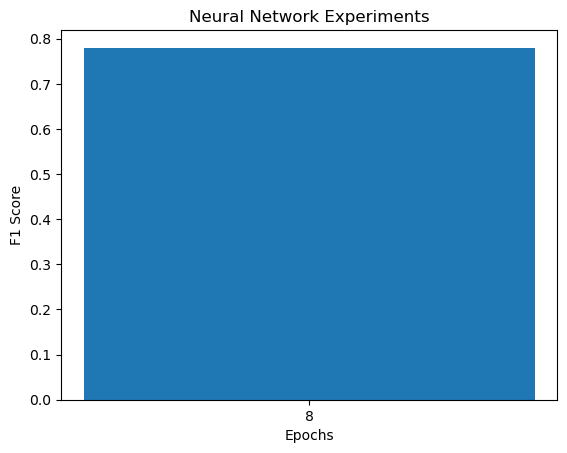

In [4]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.neural_network import MLPClassifier

from tqdm import tqdm


# CONFIGURACIÓN MLFLOW

mlflow.set_tracking_uri("http://ec2-54-174-164-37.compute-1.amazonaws.com:5000")
experiment_name = "Parcial_NLP"
mlflow.set_experiment(experiment_name)


# OUTPUT FOLDERS

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)


# CARGAR DATASET

train_df = pd.read_csv("data_nopunct_elongation/train_final.csv")
test_df = pd.read_csv("data_nopunct_elongation/test_final.csv")

train_df = train_df.sample(800000, random_state=42)

print(train_df.head())


# FEATURES

X_train = train_df["text"]
y_train = train_df["label"].values

X_test = test_df["text"]
y_test = test_df["label"].values


# TFIDF (AJUSTES 1 y 2)

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

print("\nFitting TFIDF...")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

input_dim = X_train_vec.shape[1]

print("Final feature dimension:", input_dim)


# CONFIGURACIONES (AJUSTE 4)

experiments = [
    {"batch_size":256, "epochs":8},
    {"batch_size":512, "epochs":8}
]


ablation_results = []


# LOOP EXPERIMENTOS

for exp in experiments:

    batch_size = exp["batch_size"]
    epochs = exp["epochs"]

    run_name = f"NN_batch{batch_size}_epochs{epochs}"

    print(f"\nRunning experiment {run_name}")


    with mlflow.start_run(run_name=run_name):

        mlflow.set_tags({
            "project": "NLP Sentiment Analysis",
            "dataset": "train_final.csv",
            "task": "text_classification",
            "model_type": "Neural Network",
            "feature_type": "TFIDF",
            "author": "Nicolas"
        })


        start_time = time.time()


        # RED NEURONAL 

        model = MLPClassifier(
            hidden_layer_sizes=(128,64),
            activation="relu",
            solver="adam",
            batch_size=batch_size,
            alpha=0.0001,
            max_iter=1,
            warm_start=True,
            random_state=42
        )

        classes = np.unique(y_train)

        print("\nTraining Progress:")

        pbar = tqdm(range(epochs))

        for epoch in pbar:

            if epoch == 0:
                model.partial_fit(X_train_vec, y_train, classes=classes)
            else:
                model.partial_fit(X_train_vec, y_train)

            pbar.set_description(
                f"Epoch {epoch+1}/{epochs} | Loss {model.loss_:.4f}"
            )


        y_pred = model.predict(X_test_vec)

        runtime = time.time() - start_time

        f1 = f1_score(y_test, y_pred, average="weighted")


        # PARAMS

        mlflow.log_params({
            "vectorizer":"TFIDF",
            "ngram_range":"1,2",
            "max_features":20000,
            "min_df":3,
            "max_df":0.9,
            "sublinear_tf":True,
            "model":"MLPClassifier",
            "architecture":"128-64-1",
            "batch_size":batch_size,
            "epochs":epochs,
            "alpha":0.0001
        })


        # MÉTRICAS

        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("runtime_seconds", runtime)


        # MODEL CARD

        model_card = {
            "model_name": run_name,
            "vectorizer":"TFIDF",
            "ngram_range":"1,3",
            "max_features":20000,
            "classifier":"MLPClassifier",
            "architecture":"128-64-1",
            "epochs":epochs,
            "batch_size":batch_size,
            "alpha":0.0001,
            "f1_score":float(f1),
            "author":"Nicolas"
        }

        model_card_path = f"outputs/model/model_card_{run_name}.json"

        with open(model_card_path,"w") as f:
            json.dump(model_card,f,indent=4)


        ablation_results.append({
            "vectorizer":"TFIDF",
            "model":"NeuralNetwork",
            "epochs":epochs,
            "batch_size":batch_size,
            "f1_score":f1
        })


        mlflow.log_artifact(model_card_path)

        print("\nEjecución Exitosa")
        print("F1 Score:", f1)
        print("Runtime:", runtime)

        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))


# RESULTADOS FINALES

ablation_df = pd.DataFrame(ablation_results)

ablation_df.to_csv("outputs/reports/ablation_results.csv", index=False)


plt.figure()

plt.bar(
    ablation_df["epochs"].astype(str),
    ablation_df["f1_score"]
)

plt.xlabel("Epochs")
plt.ylabel("F1 Score")
plt.title("Neural Network Experiments")

plt.savefig("outputs/reports/ablation_plot.png")


print("\nTodos los experimentos terminaron correctamente")
print("\nResultados finales:")
print(ablation_df)